# Sistemas Inteligentes - 2026.1
## Projeto 04 - Redes Adaline
Autores: Lavínia Dantas e Jefferson Bezerra


##Contexto

Este projeto tem como objetivo implementar uma rede Adaline para a classificação automática de sinais de radar ionosférico, distinguindo retornos que indicam a presença de estrutura eletrônica coerente na ionosfera daqueles que não a indicam. O monitoramento dessa camada é fundamental para garantir a precisão em sistemas de GPS, telecomunicações e na previsão de tempestades geomagnéticas, especialmente em regiões como o Brasil, que é afetado pela Anomalia de Ionização Equatorial.

Para o desenvolvimento do modelo, é utilizado o dataset Ionosphere, coletado pelo sistema de radar Goose Bay e disponibilizado pelo UCI Machine Learning Repository. O conjunto de dados é composto por 351 amostras descritas por 34 atributos contínuos, onde o rótulo binário classifica o retorno como good (presença de estrutura) ou bad (ausência de estrutura coerente).

UCI Ionosphere: https://archive.ics.uci.edu/ml/datasets/Ionosphere

## Preparação do Ambiente de Trabalho

In [1]:
# ── Importação das Bibliotecas ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

In [2]:
# Configurações de Plotagem
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams['figure.figsize'] = (10, 6)

## 1 - Carregamento do dataset

In [3]:
# ── 1. Preparação dos Dados ───────────────────────────────────────────────────
# Carregar o dataset Ionosphere direto da UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
df = pd.read_csv(url, header=None)

In [4]:
# Separar os atributos (X) do rótulo (y)
X_raw = df.iloc[:, :-1]
y_raw = df.iloc[:, -1]

In [5]:
# Recodificar os rótulos: 'g' para +1 e 'b' para -1
y = np.where(y_raw == 'g', 1, -1)

In [6]:
# Remover atributos constantes (colunas com apenas 1 valor único)
X_raw = X_raw.loc[:, X_raw.nunique() > 1]

In [7]:
# Divisão em treino (80%) e teste (20%) com amostragem estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# Aplicar a normalização Z-score
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

A normalização dos dados é essencial para o funcionamento adequado da rede Adaline, pois o algoritmo utiliza a regra Delta baseada em gradiente descendente.

Algebricamente, a atualização dos pesos na Adaline é dada por: w = w + η * x * erro

Onde x representa as entradas. Caso as variáveis possuam escalas muito diferentes, os atributos com valores maiores dominarão a atualização dos pesos, tornando o processo instável.

Isso pode causar oscilações excessivas na função de custo (MSE) ou até divergência do treinamento, especialmente para taxas de aprendizagem maiores.

A padronização via Z-score garante que todas as variáveis tenham média zero e variância unitária, estabilizando o processo de aprendizado e permitindo uma convergência mais suave e eficiente.

In [9]:
print(f"Amostras de treino: {X_train.shape[0]}")
print(f"Amostras de teste : {X_test.shape[0]}")
print(f"Features retidas  : {X_train.shape[1]}")

Amostras de treino: 280
Amostras de teste : 71
Features retidas  : 33


## 2 - Estudo da Taxa de Aprendizagem ($\eta$)

<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_14737/4098389802.py:30: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(range(n_epochs), custos_epoca, label=f'$\eta = {eta}$')


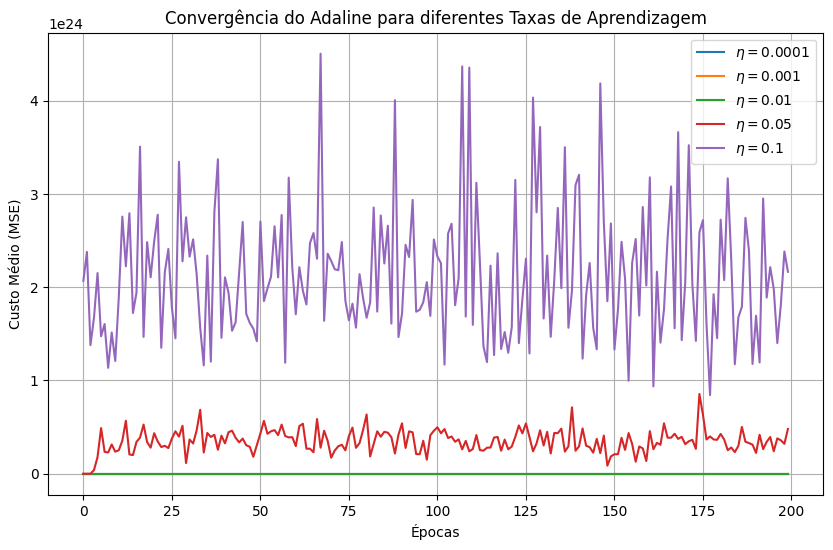

In [10]:
# ── 2. Implementação e Estudo da Taxa de Aprendizagem ────────────────────────
etas = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
n_epochs = 200

plt.figure()

for eta in etas:
    # Inicializar o Adaline (SGDClassifier com erro quadrático)
    adaline = SGDClassifier(
        loss='squared_error',
        learning_rate='constant',
        eta0=eta,
        shuffle=True,
        random_state=42
    )

    custos_epoca = []

    # Loop manual de épocas para registrar o custo
    for epoch in range(n_epochs):
        # partial_fit executa uma iteração sobre os dados (1 época)
        adaline.partial_fit(X_train, y_train, classes=np.unique(y_train))

        # Calcular a saída linear u e o Erro Quadrático Médio
        u = adaline.decision_function(X_train)
        mse = np.mean((y_train - u) ** 2) / 2
        custos_epoca.append(mse)

    # Plotar a curva de convergência para o eta atual
    plt.plot(range(n_epochs), custos_epoca, label=f'$\eta = {eta}$')

plt.xlabel('Épocas')
plt.ylabel('Custo Médio (MSE)')
plt.title('Convergência do Adaline para diferentes Taxas de Aprendizagem')
plt.legend()
plt.grid(True)
plt.show()

A análise das curvas de convergência mostra que taxas de aprendizagem muito altas, como η = 0.1, causam instabilidade no treinamento, com valores de erro extremamente elevados e comportamento oscilatório, indicando divergência.

Por outro lado, taxas muito pequenas, como η = 0.0001, tendem a apresentar convergência muito lenta, dificultando o aprendizado dentro do número limitado de épocas.

A taxa η = 0.01 apresentou o melhor equilíbrio, com convergência estável e redução consistente da função de custo ao longo das épocas.Sendo assim, essa taxa foi escolhida por proporcionar aprendizado eficiente e comportamento estável do modelo.

## 3 - Avaliação do Modelo Final

In [11]:
# ── 3. Classificação e Métricas com o Melhor eta ───
# Substitua pelo melhor valor identificado no gráfico!
melhor_eta = 0.01

adaline_final = SGDClassifier(
    loss='squared_error',
    learning_rate='constant',
    eta0=melhor_eta,
    max_iter=200,
    shuffle=True,
    random_state=42
)

# Treinamento com o melhor eta
adaline_final.fit(X_train, y_train)

# Previsão nas amostras de teste
y_pred = adaline_final.predict(X_test)

# Cálculo das métricas
conf_matrix = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred) # Precisão para a classe +1
rec = recall_score(y_test, y_pred)     # Recall para a classe +1
f1 = f1_score(y_test, y_pred)          # F1-Score para a classe +1

print("--- Avaliação do Modelo ---")
print(f"Melhor Taxa de Aprendizagem escolhida: {melhor_eta}")
print("\nMatriz de Confusão:")
print(conf_matrix)
print(f"\nAcurácia Global: {acc:.4f}")
print(f"Precisão (+1)  : {prec:.4f}")
print(f"Recall (+1)    : {rec:.4f}")
print(f"F1-Score (+1)  : {f1:.4f}")

# Métricas detalhadas para a classe bad (-1)
# O recall da classe -1 é especialmente importante conforme a questão 4
prec_bad = precision_score(y_test, y_pred, pos_label=-1)
rec_bad = recall_score(y_test, y_pred, pos_label=-1)

print("\nMétricas para a classe 'bad' (-1):")
print(f"Precisão (-1)  : {prec_bad:.4f}")
print(f"Recall (-1)    : {rec_bad:.4f}")

--- Avaliação do Modelo ---
Melhor Taxa de Aprendizagem escolhida: 0.01

Matriz de Confusão:
[[23  2]
 [ 0 46]]

Acurácia Global: 0.9718
Precisão (+1)  : 0.9583
Recall (+1)    : 1.0000
F1-Score (+1)  : 0.9787

Métricas para a classe 'bad' (-1):
Precisão (-1)  : 1.0000
Recall (-1)    : 0.9200


O modelo apresentou excelente desempenho, com acurácia global de aproximadamente 97%, indicando alta taxa de acertos. A matriz de confusão mostra que o modelo classificou corretamente a maioria das amostras, com poucos erros. Destaca-se o recall da classe "good" (+1), que atingiu valor máximo (1.0), indicando que todas as amostras dessa classe foram corretamente identificadas.

Para a classe "bad" (-1), o modelo apresentou alta precisão (1.0) e recall de 0.92, indicando bom desempenho, embora ainda existam alguns casos de erro. De modo geral, o modelo demonstrou alta capacidade de generalização e separação entre as classes.

No contexto do problema, a classe "bad" (-1) representa ausência de estrutura ionosférica, o que pode indicar falhas de transmissão ou interferência no sistema. O erro mais crítico, portanto, é classificar uma amostra da classe "bad" como "good" (falso positivo).

Esse tipo de erro pode levar o sistema a interpretar erroneamente que a ionosfera está em condições adequadas, quando na verdade há problemas, comprometendo aplicações como telecomunicações e navegação. Dessa forma, é mais importante minimizar falsos positivos para a classe "good", garantindo maior confiabilidade no monitoramento.